# METRO INTERSTATE TRAFFIC

In [ ]:
# IMPORTING LIBRARIES FOR DATA HANDLING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#LOADING THE DATASET
df=pd.read_csv("/content/Metro_Interstate_Traffic_Volume.csv")
df.head()

,traffic_volume,temp,clouds_all,weather_main,weather_description,date_time
0,5545,288.28,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,289.36,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,289.58,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,290.13,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,291.14,75,Clouds,broken clouds,02-10-2012 13:00


In [ ]:
df.tail()

,traffic_volume,temp,clouds_all,weather_main,weather_description,date_time
48199,3543,283.45,75,Clouds,broken clouds,30-09-2018 19:00
48200,2781,282.76,90,Clouds,overcast clouds,30-09-2018 20:00
48201,2159,282.73,90,Thunderstorm,proximity thunderstorm,30-09-2018 21:00
48202,1450,282.09,90,Clouds,overcast clouds,30-09-2018 22:00
48203,954,282.12,90,Clouds,overcast clouds,30-09-2018 23:00


In [ ]:
df=df.drop(["weather_description"],axis=1)

In [ ]:
df.head()

,traffic_volume,temp,clouds_all,weather_main,date_time
0,5545,288.28,40,Clouds,02-10-2012 09:00
1,4516,289.36,75,Clouds,02-10-2012 10:00
2,4767,289.58,90,Clouds,02-10-2012 11:00
3,5026,290.13,90,Clouds,02-10-2012 12:00
4,4918,291.14,75,Clouds,02-10-2012 13:00


In [ ]:
# Convert date_time column into datetime format for time series analysis
df['date_time'] = pd.to_datetime(df['date_time'], format="%d-%m-%Y %H:%M")

# Set date_time as index so that time becomes the main reference
df.set_index('date_time', inplace=True)

In [ ]:
#Sort data
df=df.sort_index()
df=df[['traffic_volume']]

In [ ]:
# Fill missing values using forward fill method
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_11335/3354253984.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


RESAMPLING

In [ ]:

#Convert hourly data into daily average to reduce noise and improve visualization

df_daily=df.resample('D').mean()
df_daily.head()

,traffic_volume
date_time,
2012-10-02,4219.266667
2012-10-03,3317.250000
2012-10-04,3747.458333
2012-10-05,4242.545455
2012-10-06,3256.956522


PLOTTING DATA

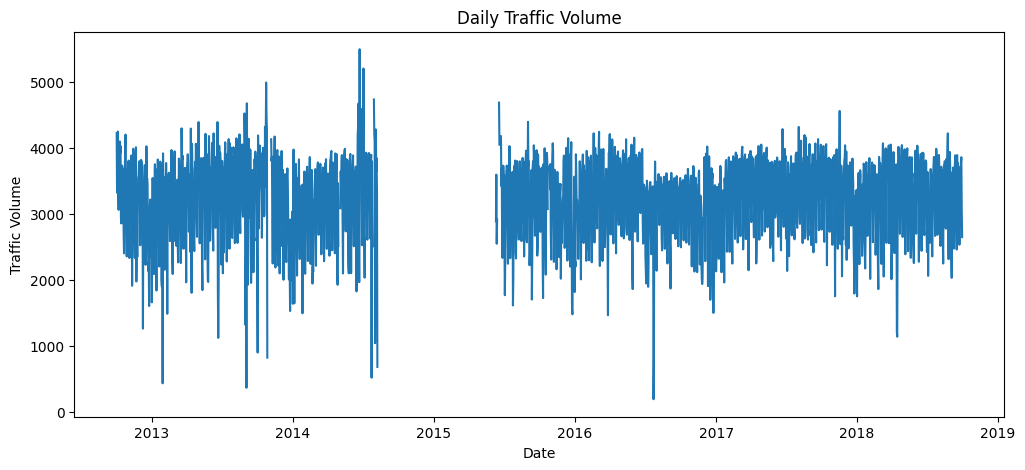

In [ ]:
#Plotting daily traffic volume to observe trend
plt.figure(figsize=(12,5))
plt.plot(df_daily)
plt.title("Daily Traffic Volume")
plt.xlabel("Date")
plt.ylabel("Traffic Volume")
plt.show()

MOVING AVERAGE(TREND)

In [ ]:
df_daily['rolling_mean'] = df_daily['traffic_volume'].rolling(window=7).mean()

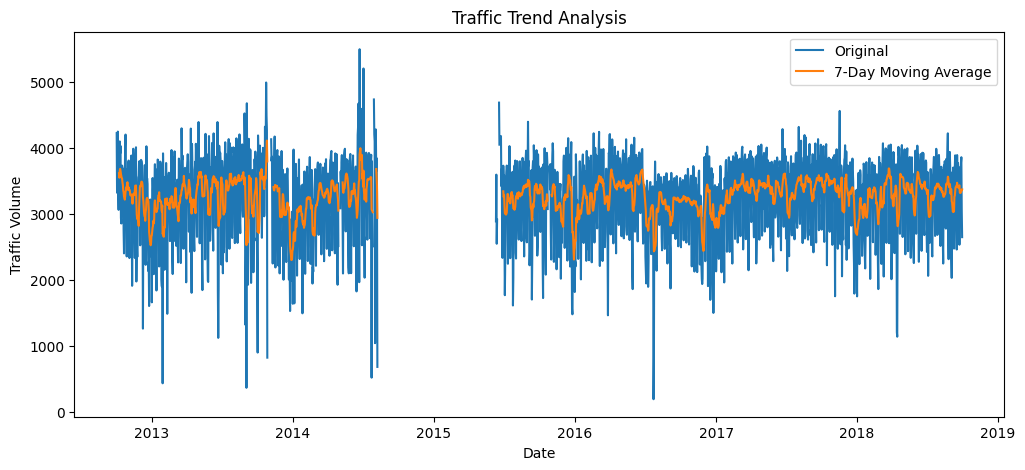

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df_daily['traffic_volume'], label='Original')
plt.plot(df_daily['rolling_mean'], label='7-Day Moving Average')
plt.legend()
plt.title("Traffic Trend Analysis")
plt.xlabel("Date")
plt.ylabel("Traffic Volume")
plt.show()

SEASONALITY(DAY-WISE)

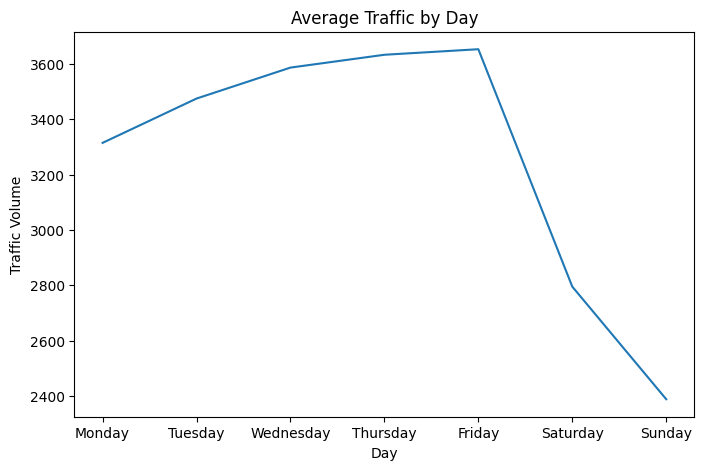

In [ ]:
# Create day column
df_daily['day'] = df_daily.index.day_name()

# Average traffic per day
day_avg = df_daily.groupby('day')['traffic_volume'].mean()

# Correct order
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_avg = day_avg.reindex(order)

# Plot
plt.figure(figsize=(8,5))
plt.plot(day_avg)
plt.title("Average Traffic by Day")
plt.xlabel("Day")
plt.ylabel("Traffic Volume")
plt.show()

In [ ]:
ts=df_daily['traffic_volume']

In [ ]:
#Splitting data into training and testing data

train = ts[:'2017']
test = ts['2018':]

split = int(len(ts)*0.8)
train = ts[:split]
test = ts[split:]

APPLYING ARIMA

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

In [ ]:
pred = model_fit.forecast(steps=len(test))

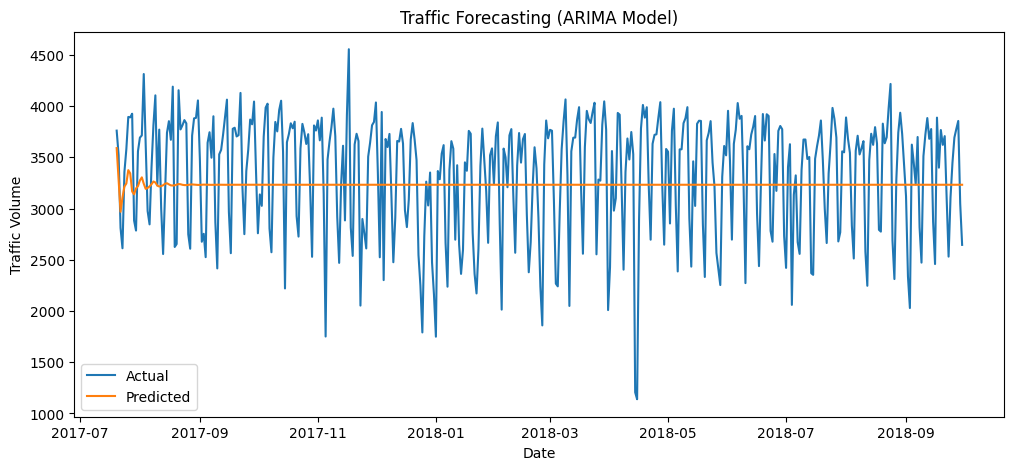

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, pred, label='Predicted')
plt.legend()
plt.title("Traffic Forecasting (ARIMA Model)")
plt.xlabel("Date")
plt.ylabel("Traffic Volume")
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test, pred)
print("MAE:", mae)

MAE: 502.2865970377052


APPLYING SARIMA

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train, order=(5,1,0), seasonal_order=(1,1,1,7))
model_fit = model.fit()

pred = model_fit.forecast(steps=len(test))

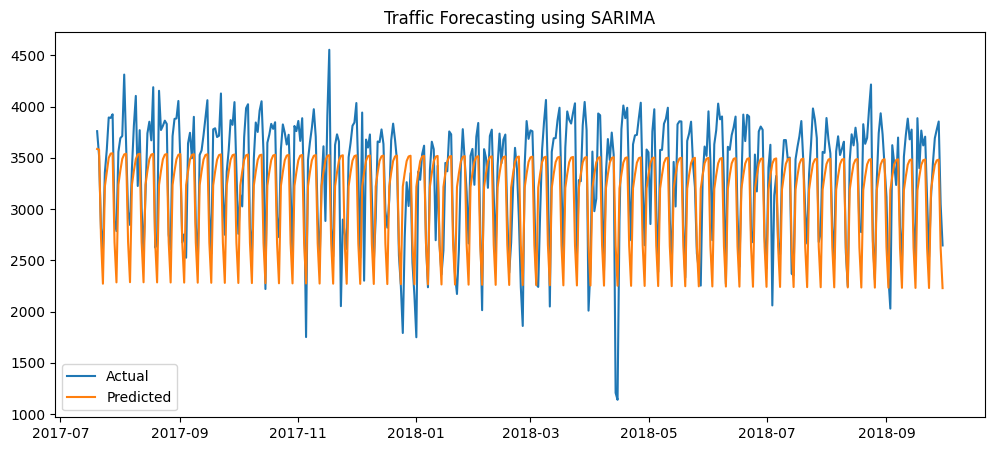

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, pred, label='Predicted')
plt.legend()
plt.title("Traffic Forecasting using SARIMA")
plt.show()